In [51]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import sys

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

In [52]:
input_size = 9 # number of features in the input
hidden_size = 16 # number of features in the hidden state
num_layers = 1 # number of recurrent layers
activation_fun = "tanh" # activation function to use in the RNN cell
bias = True # whether to include a bias term in the RNN cell

# create an RNN instance
rnn = nn.RNN(input_size=input_size,
             hidden_size=hidden_size,
             num_layers=num_layers,
             nonlinearity=activation_fun,
             bias=bias)

# print the RNN architecture
print(rnn)

RNN(9, 16)


In [53]:
sequence_length = 5 # length of the input sequence
batch_size = 2 # number of sequences in a batch

# create a random input tensor of shape (sequence_length, batch_size, input_size)
input_tensor = torch.randn(sequence_length, batch_size, input_size)

# create a random initial hidden state tensor of shape (num_layers, batch_size, hidden_size), typically initialized to zeros
h0 = torch.zeros(num_layers, batch_size, hidden_size)

# run the RNN on the input tensor and initial hidden state
output, hn = rnn(input_tensor, h0)

print("Input shape:", input_tensor.shape) # should be (sequence_length, batch_size, input_size)
print("Hidden state shape:", hn.shape) # should be (num_layers, batch_size, hidden_size)
print("Output shape:", output.shape) # should be (sequence_length, batch_size, hidden_size)

Input shape: torch.Size([5, 2, 9])
Hidden state shape: torch.Size([1, 2, 16])
Output shape: torch.Size([5, 2, 16])


In [54]:
output_default, hn_default1 = rnn(input_tensor)
output_default, hn_default2 = rnn(input_tensor, h0)

hn_default1 - hn_default2 # should be a tensor of zeros, indicating that the default initial hidden state is the same as the provided initial hidden state (h0)

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]],
       grad_fn=<SubBackward0>)

In [55]:
for name, param in rnn.named_parameters():
    print(name, param.shape)

weight_ih_l0 torch.Size([16, 9])
weight_hh_l0 torch.Size([16, 16])
bias_ih_l0 torch.Size([16])
bias_hh_l0 torch.Size([16])


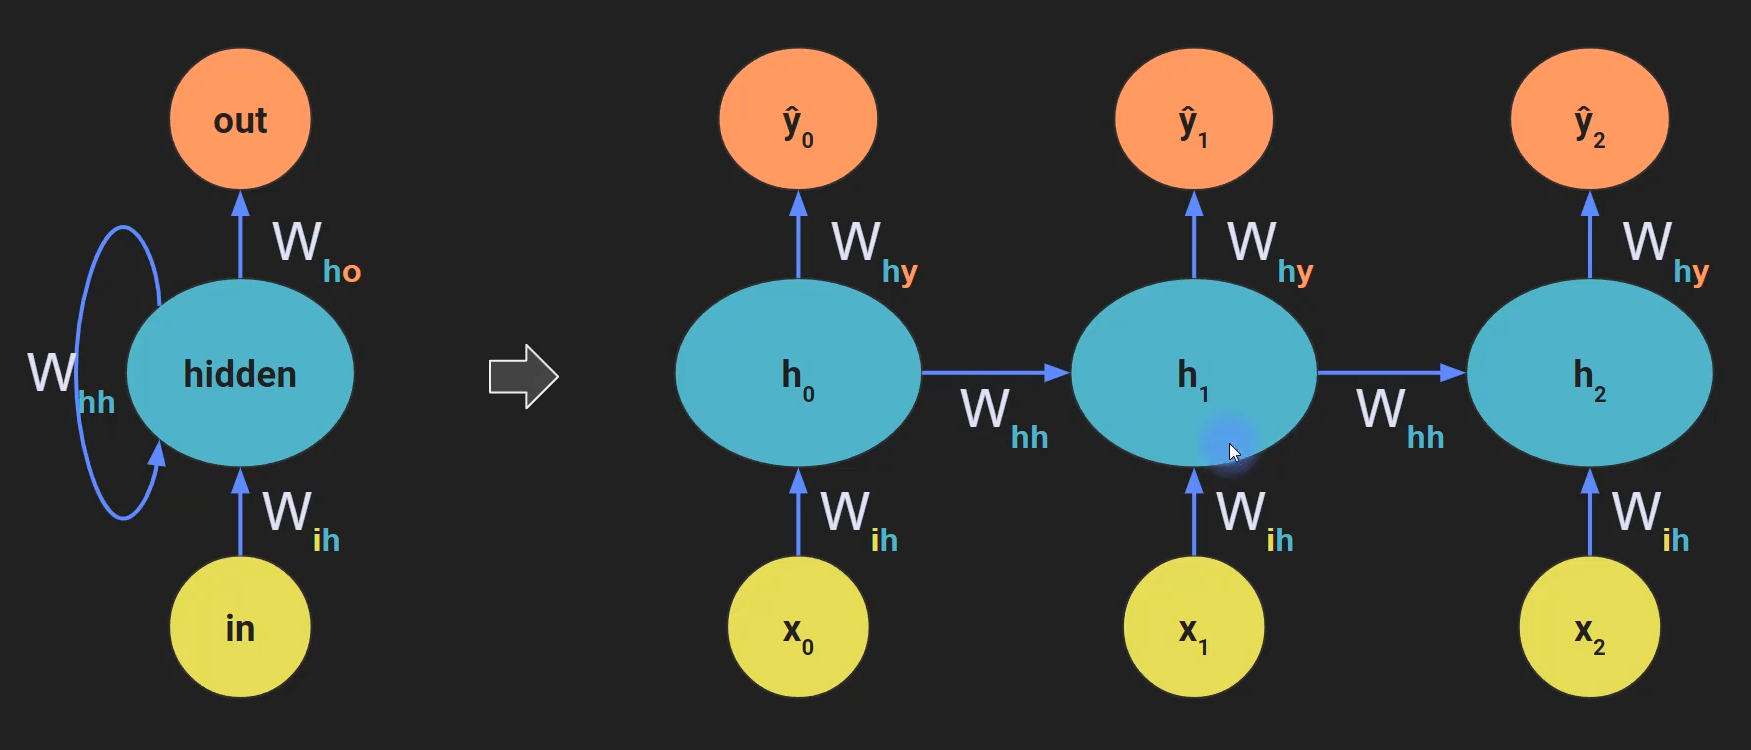

In [56]:
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, activation_fun='tanh', bias=True):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          nonlinearity=activation_fun,
                          bias=bias)
        
        # linear layer to map the hidden state to the output
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x, h0=None):
        x, hn = self.rnn(x, h0) # if h0 is None, the RNN will initialize it to zeros
        x = self.linear(x)
        return x, hn

In [57]:
rrn_net = RNNModel(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers)

for name, param in rrn_net.named_parameters():
    print(name, param.shape)

rnn.weight_ih_l0 torch.Size([16, 9])
rnn.weight_hh_l0 torch.Size([16, 16])
rnn.bias_ih_l0 torch.Size([16])
rnn.bias_hh_l0 torch.Size([16])
linear.weight torch.Size([1, 16])
linear.bias torch.Size([1])


In [58]:
X = torch.randn(sequence_length, batch_size, input_size)
y = torch.randn(sequence_length, batch_size, 1)
output, hn = rrn_net(X)

# try a loss function
criterion = nn.MSELoss()
criterion(output, y)

tensor(1.4785, grad_fn=<MseLossBackward0>)

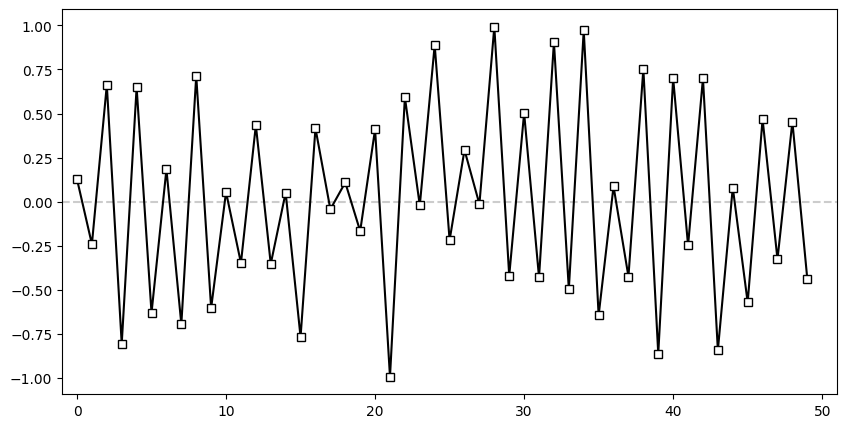

In [59]:
N = 50

data = torch.zeros(N)

for i in range(N):
    data[i] = torch.rand(1) * (-1) ** i # alternating positive and negative random numbers

plt.figure(figsize=(10, 5))
plt.plot([-1, N+1], [0, 0], "--", color=[0.8, 0.8, 0.8]) # add a horizontal line at y=0 for reference
plt.plot(data.numpy(), "ks-", markerfacecolor="w")
plt.xlim(-1, N+1)
plt.show()

In [60]:
input_size = 1 # number of features in the input
hidden_size = 5 # number of features in the hidden state
num_layers = 1 # number of recurrent layers
sequence_length = 9 # length of the input sequence
batch_size = 1 # number of sequences in a batch

rrn_net = RNNModel(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers)

# test the model with some data
X_test_data = data[:sequence_length].view(sequence_length, batch_size, input_size) # reshape the data to match the expected input shape of the model
y_test, hn_test = rrn_net(X_test_data)
print("Test input shape:", X_test_data.shape) # should be (sequence_length, batch_size, 1)
print("Test hidden state shape:", hn_test.shape) # should be (num_layers, batch_size, hidden_size)
print("Test output shape:", y_test.shape) # should be (sequence_length, batch_size, 1)

loss_fn = nn.MSELoss()
loss = loss_fn(y_test, X_test_data) # using the input data as the target
print(f"Test loss: {loss.item():.2f}")

Test input shape: torch.Size([9, 1, 1])
Test hidden state shape: torch.Size([1, 1, 5])
Test output shape: torch.Size([9, 1, 1])
Test loss: 0.46


In [ ]:
def train(model, data, loss_fn, optimizer, num_epochs):

    model.train() # set the model to training mode

    losses = np.zeros(num_epochs)
    sign_accuracy = np.zeros(num_epochs)

    for epoch in range(num_epochs):
        sequence_losses = []
        sequence_accuracies = []

        for time_i in range(len(data) - sequence_length):
            # prepare the input and target sequences
            input_seq = data[time_i:time_i+sequence_length].view(sequence_length, batch_size, input_size)
            target_seq = data[time_i+sequence_length].view(batch_size, input_size) # target is the next value in the sequence

            output, _ = model(input_seq) # forward pass
            final_output = output[-1] # take the output of the last time step
            loss = loss_fn(final_output, target_seq) # compute the loss

            optimizer.zero_grad() # clear the gradients
            loss.backward() # backward pass
            optimizer.step() # update the model parameters

            sequence_losses.append(loss.item())

            # compute the sign accuracy, not the value
            predicted_sign = torch.sign(final_output).item()
            target_sign = torch.sign(target_seq).item()
            sequence_accuracies.append(predicted_sign == target_sign)

        losses[epoch] = np.mean(sequence_losses) # average loss for the epoch
        sign_accuracy[epoch] = np.mean(sequence_accuracies) # average sign accuracy for the epoch

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {losses[epoch]:.4f}, Sign Accuracy: {sign_accuracy[epoch]:.4f}")

    return losses, sign_accuracy

In [62]:
num_epochs = 30
rnn_net = RNNModel(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers)
optimizer = torch.optim.SGD(rnn_net.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
losses, sign_acc = train(rnn_net, data, loss_fn, optimizer, num_epochs)

Epoch [10/30], Loss: 0.2769, Sign Accuracy: 0.5122
Epoch [20/30], Loss: 0.2220, Sign Accuracy: 1.0000
Epoch [30/30], Loss: 0.1728, Sign Accuracy: 1.0000


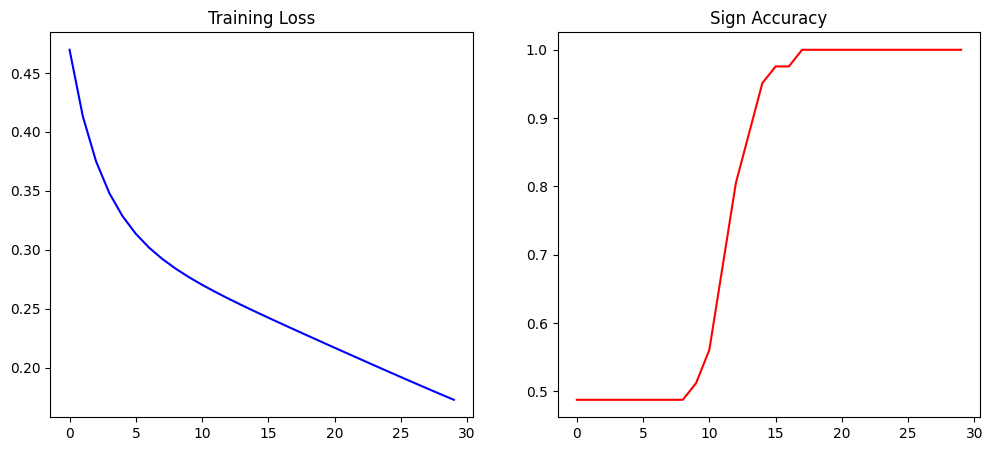

In [ ]:
# plot the training loss and sign accuracy
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(losses, "b-")
ax[0].set_title("Training Loss")
ax[1].plot(sign_acc, "r-")
ax[1].set_title("Sign Accuracy")
plt.show()

# the accuracy is measured in terms of the sign of the output, not the value, since the task is to predict whether the next value in the sequence is positive or negative, 
# not its exact value.

In [ ]:
# now test the trained model on training data

# initialize the hidden state to zeros
h_list = torch.zeros((N, hidden_size)) # store the hidden state for each time step

# initialize the predicted values
predicted_values = np.zeros(len(data))

# loop through the data and make predictions using the trained model
for time_i in range(len(data) - sequence_length):
    input_seq = data[time_i:time_i+sequence_length].view(sequence_length, batch_size, input_size)
    output, hh = rnn_net(input_seq) # use the last hidden state as the initial hidden state for the next prediction
    predicted_values[time_i + sequence_length] = output[-1] # store the predicted value
    h_list[time_i + sequence_length] = hh.detach() # store the hidden state for visualization

# compute the sign accuracy of the predictions
predicted_signs = np.sign(predicted_values)
true_signs = np.sign(data.numpy())
sign_accuracy = np.mean(predicted_signs[sequence_length:] == true_signs[sequence_length:])

# the model is always using 9 sequence points in this case to predict the next point, for that reason, the first 9 predicted values are not used to compute the accuracy, 
# since they are not based on a full sequence of 9 points.

C:\Users\Pablo\AppData\Local\Temp\ipykernel_4724\1024277819.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[1].plot(data - predicted_values, "ms", label="Prediction Error")


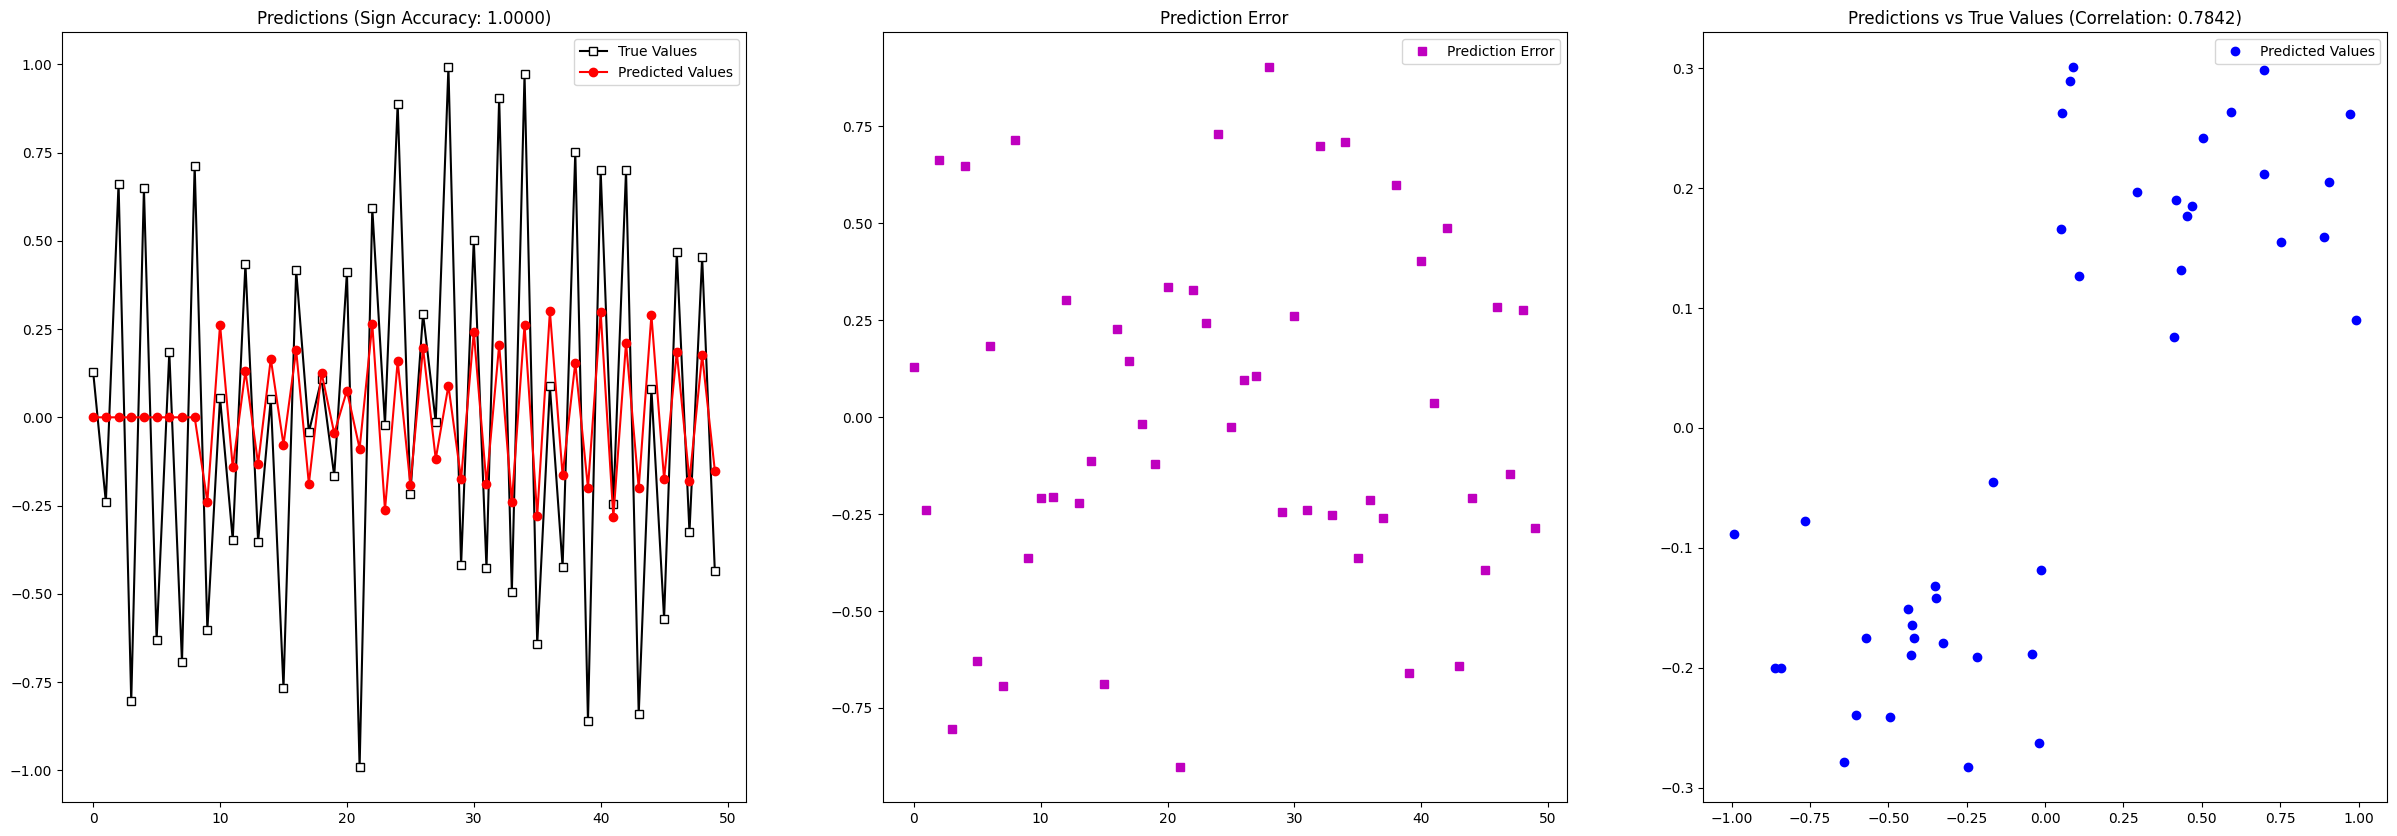

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(30, 10))

ax[0].plot(data.numpy(), "ks-", markerfacecolor="w", label="True Values")
ax[0].plot(predicted_values, "ro-", label="Predicted Values")
ax[0].set_title(f"Predictions (Sign Accuracy: {sign_accuracy:.4f})")
ax[0].legend()

ax[1].plot(data - predicted_values, "ms", label="Prediction Error")
ax[1].set_title("Prediction Error")
ax[1].legend()
# we observe that the error is between -1 and 1, which makes sense since the model is learning to predict the sign of the next value, not its exact value.

ax[2].plot(data[sequence_length:], predicted_values[sequence_length:], "bo", label="Predicted Values")
r = np.corrcoef(data[sequence_length:].numpy(), predicted_values[sequence_length:])[0, 1]
ax[2].set_title(f"Predictions vs True Values (Correlation: {r:.4f})")
ax[2].legend()
# the correlation is quite high ~0.8, but there is no linear correlation, since we observe there are two clusters of points, one for the positive values 
# and one for the negative values, which makes sense since the model is learning to predict the sign of the next value, not its exact value.
# in those clusters, we see there is no correlation between the predicted and true values. so some metrics like R2 would not be appropriate to evaluate the model, 
# since they assume a linear relationship between the predicted and true values, which is not the case here.

Hidden state shape: torch.Size([50, 5])


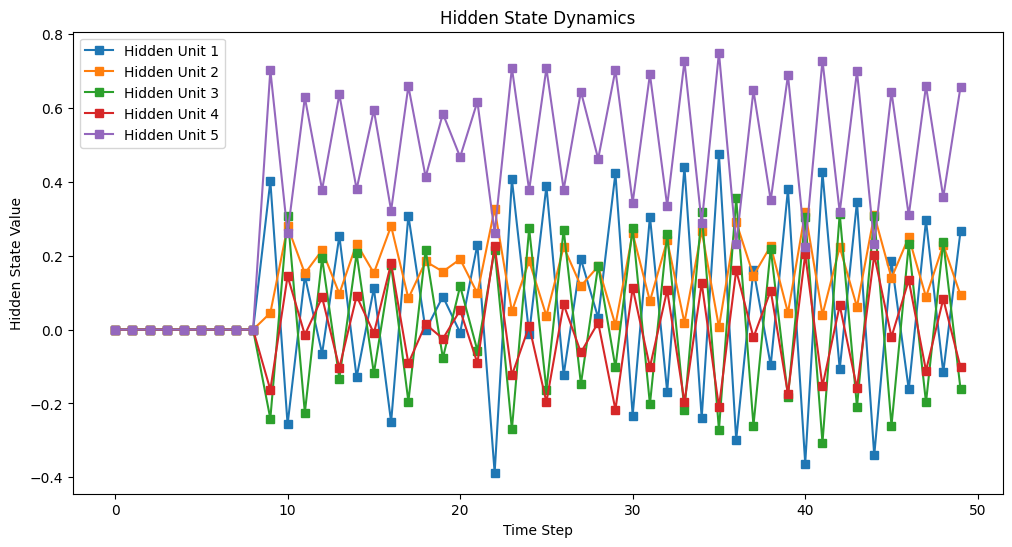

In [79]:
# plot hidden state dynamics
print(f"Hidden state shape: {h_list.shape}") # should be (N, hidden_size)
plt.figure(figsize=(12, 6))
for i in range(hidden_size):
    plt.plot(h_list[:, i].numpy(), "s-", label=f"Hidden Unit {i+1}")
plt.title("Hidden State Dynamics")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.legend()
plt.show()

C:\Users\Pablo\AppData\Local\Temp\ipykernel_4724\3805893226.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[1].plot(newdata - predicted_values_new, "ms", label="Prediction Error")


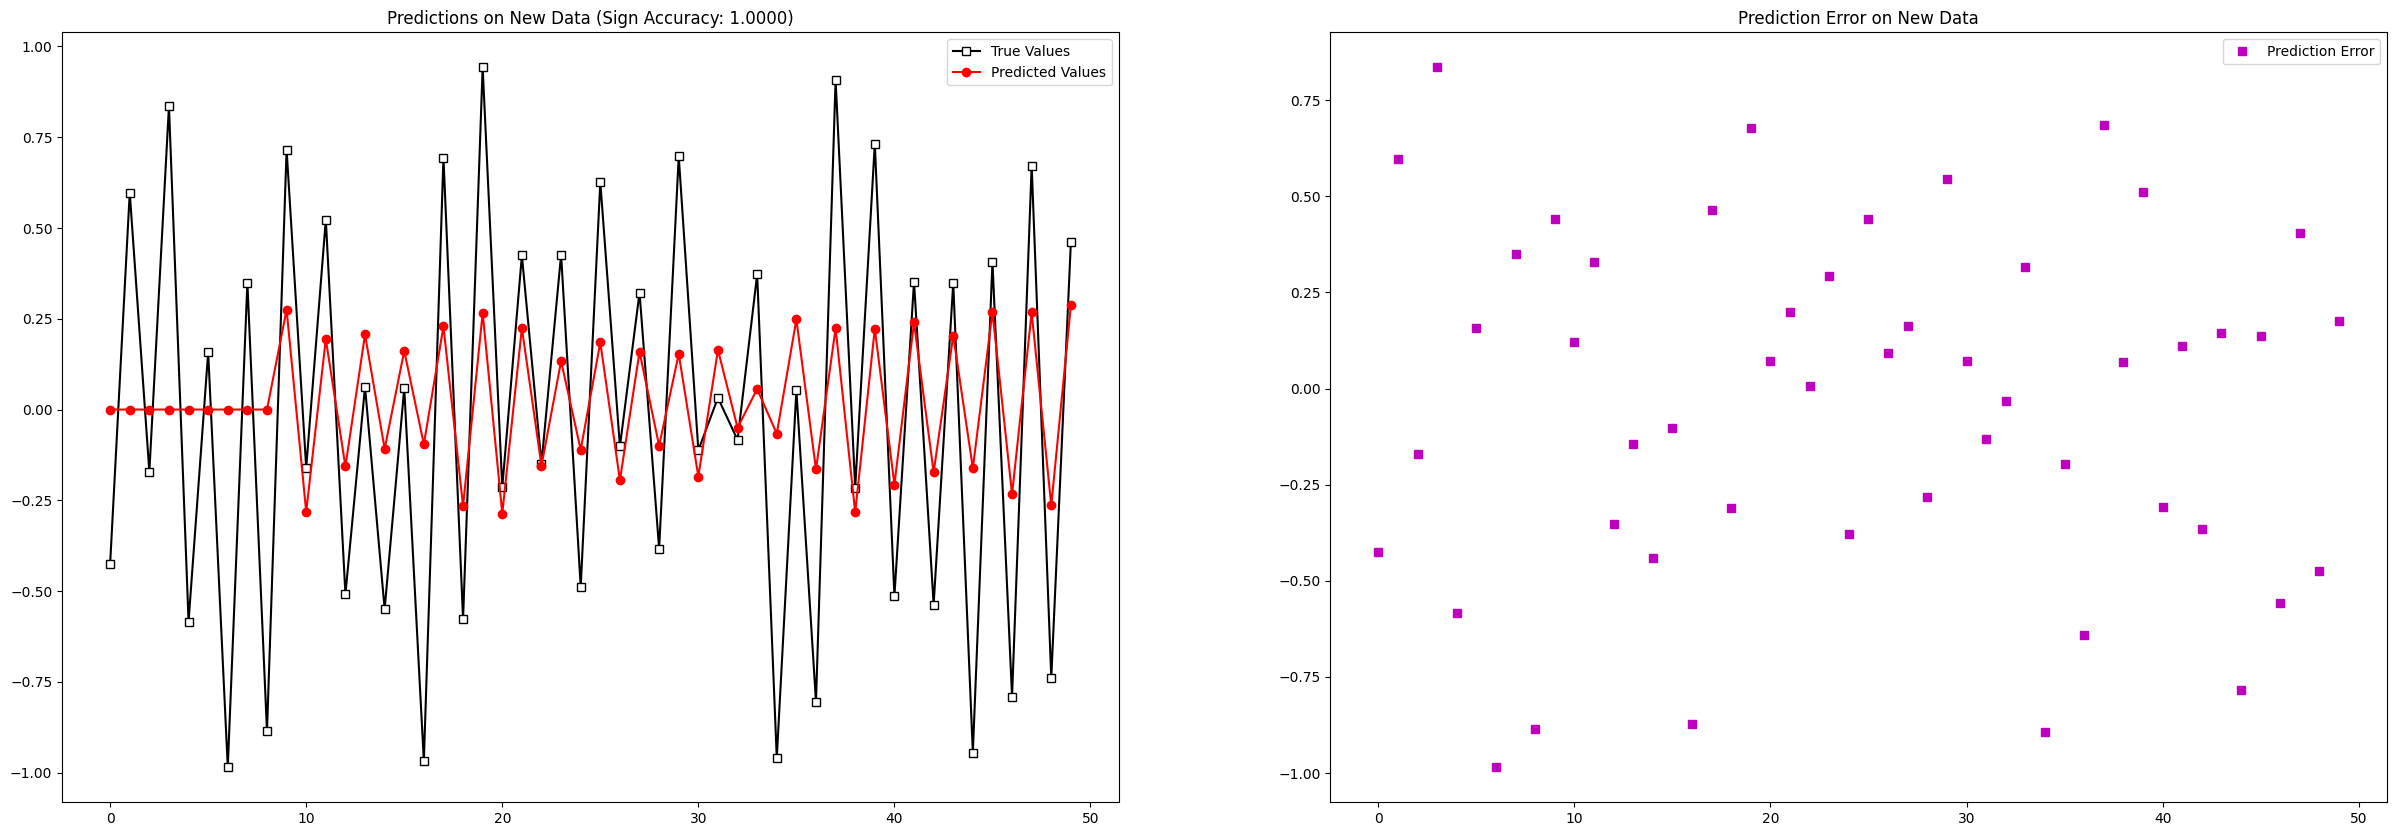

In [81]:
# we haven't tested the model on a separate test set, since the data is very small and we are just trying to understand how RNNs work
# let's test it with new data
newdata = torch.zeros(N)
for i in range(N):
    newdata[i] = torch.rand(1) * (-1) ** (i + 1) # alternating positive and negative random numbers, but with opposite sign to the training data

predicted_values_new = np.zeros(len(newdata))

for time_i in range(len(newdata) - sequence_length):
    input_seq = newdata[time_i:time_i+sequence_length].view(sequence_length, batch_size, input_size)
    output, hh = rnn_net(input_seq) # use the last hidden state as the initial hidden state for the next prediction
    predicted_values_new[time_i + sequence_length] = output[-1] # store the predicted value

predicted_signs_new = np.sign(predicted_values_new)
true_signs_new = np.sign(newdata.numpy())
sign_accuracy_new = np.mean(predicted_signs_new[sequence_length:] == true_signs_new[sequence_length:])

fig, ax = plt.subplots(1, 2, figsize=(30, 10))
ax[0].plot(newdata.numpy(), "ks-", markerfacecolor="w", label="True Values")
ax[0].plot(predicted_values_new, "ro-", label="Predicted Values")
ax[0].set_title(f"Predictions on New Data (Sign Accuracy: {sign_accuracy_new:.4f})")
ax[0].legend()

ax[1].plot(newdata - predicted_values_new, "ms", label="Prediction Error")
ax[1].set_title("Prediction Error on New Data")
ax[1].legend()